# 04 — AI Developer Tools

## Question

How large is the observed developer-tools slice in the Harpd discovery index, where
were those products observed, and does it overlap the agent slice?

This notebook is the evidence base for the Harpd developer-tools index. A companion
report is generated by `scripts/generate_reports.py`.


## Dataset

| Item | Value |
|---|---|
| File | `data/research/developer-tools-index.json` |
| Records | 1,918 |
| Slice definition | `category == ['developer']` |
| Raw base | `https://raw.githubusercontent.com/harpd-dev/harpd-ai-datasets/main/` |
| Licence | CC BY 4.0 |

**Domain caveat.** Rank Points are promotional placement bought with Credits — NOT
an editorial quality score.


## Method

1. Load the developer-tools slice.
2. `analysis.discovery_coverage` summarises size, domains and rank-board reach.
3. `analysis.discovery_sources` counts records per discovery source.
4. `analysis.cross_index_overlap` joins this slice against the agent and AI-tools
   slices on domain to measure how much they share.
5. Tabulate the category-confidence distribution to expose classification quality.


## Analysis

In [1]:
import os
import sys
from pathlib import Path

# Make the repository root importable no matter where Jupyter was started.
ROOT = Path.cwd()
while not (ROOT / "harpd_research").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from harpd_research import analysis, loader

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)

print("repo root :", ROOT)
print("data base :", loader.resolved_data_base())
print("pandas    :", pd.__version__)
print()
print("DOMAIN CAVEAT")
print(analysis.PLACEMENT_CAVEAT)


repo root : /Users/shankou/harpd/harpd-ai-research-notebooks
data base : https://raw.githubusercontent.com/harpd-dev/harpd-ai-datasets/main/
pandas    : 3.0.5

DOMAIN CAVEAT
Rank Points are promotional placement bought with Credits — NOT an editorial quality score. Any ordering below is a promotional placement ordering, not a ranking of product quality.


In [2]:
devtools = loader.load_developer_tools_index()

print("records     :", len(devtools))
print("generatedAt :", devtools.attrs.get("generatedAt"))
print("slice       :", devtools.attrs.get("sliceDefinition"))
print("disclosure  :", devtools.attrs.get("disclosure"))
print()
display(devtools.head(3)[["name", "domain", "category", "category_confidence", "discovered_from"]])

records     : 1918
generatedAt : 2026-09-09T06:33:49.935Z
slice       : {'category': ['developer']}
disclosure  : Coverage view sliced from the Harpd Product Discovery Index by product category. Not a ranking.



,name,domain,category,category_confidence,discovered_from
0,0din.ai,0din.ai,developer,0.5,uneed.best
1,123VideoTool,123videotool.com,developer,0.5,uneed.best
2,2Extract,2extract.com,developer,1.0,uneed.best


In [3]:
coverage = analysis.discovery_coverage(devtools, "Developer tools index")
display(pd.DataFrame([coverage]).T.rename(columns={0: "value"}))

,value
label,Developer tools index
records,1918
distinctDomains,1918
onRankBoard,0
onRankBoardPct,0.0
meanCategoryConfidence,0.5103
distinctDiscoverySources,15
observedAtMin,2026-09-09T05:32:38.234000+00:00
observedAtMax,2026-09-09T05:58:30.223000+00:00
hasData,True


In [4]:
sources = analysis.discovery_sources(devtools, top_n=10)
print(f"{coverage['distinctDiscoverySources']} distinct discovery sources")
display(sources)

15 distinct discovery sources


,discovered_from,recordCount,sharePct
0,uneed.best,1556,81.13
1,whatlaunched.today,112,5.84
2,outbid.lol,112,5.84
3,appsumo.com,87,4.54
4,lastspot.lol,16,0.83
5,toolify.ai,8,0.42
6,vibewar.lol,7,0.36
7,biddirectory.lol,5,0.26
8,claimrank.lol,5,0.26
9,frontpage.sh,3,0.16


In [5]:
confidence = (
    devtools["category_confidence"].value_counts()
    .rename_axis("category_confidence").reset_index(name="records")
    .sort_values("category_confidence").reset_index(drop=True)
)
confidence["sharePct"] = (confidence["records"] / len(devtools) * 100).round(2)
display(confidence)

print(f"mean confidence : {devtools['category_confidence'].mean():.4f}")
print(f"at 1.0          : {int((devtools['category_confidence'] >= 1.0).sum()):,}")
print(f"at or below 0.5 : {int((devtools['category_confidence'] <= 0.5).sum()):,}")

,category_confidence,records,sharePct
0,0.17,220,11.47
1,0.33,3,0.16
2,0.50,1375,71.69
3,0.67,203,10.58
4,0.83,1,0.05
5,1.00,116,6.05


mean confidence : 0.5103
at 1.0          : 116
at or below 0.5 : 1,598


In [6]:
agents = loader.load_ai_agent_index()
aitools = loader.load_ai_tools_index()

overlap = analysis.cross_index_overlap(
    {
        "developer-tools-index": devtools,
        "ai-agent-index": agents,
        "ai-tools-index": aitools,
    }
)
print("Domains appearing in more than one index:", len(overlap))
if overlap.empty:
    print("No domain is shared between the developer slice and the other slices.")
else:
    display(overlap.head(10))
    print()
    print("overlap by index pair:")
    print(overlap["indexes"].value_counts().to_string())

Domains appearing in more than one index: 334


,domain,indexCount,indexes
0,13finsight.com,2,"ai-agent-index, ai-tools-index"
1,2pr.io,2,"ai-agent-index, ai-tools-index"
2,act101.ai,2,"ai-agent-index, ai-tools-index"
3,actionagents.co,2,"ai-agent-index, ai-tools-index"
4,activitysmith.com,2,"ai-agent-index, ai-tools-index"
5,adaptprogressevolve.com,2,"ai-agent-index, ai-tools-index"
6,adgrow.net,2,"ai-agent-index, ai-tools-index"
7,adkit.so,2,"ai-agent-index, ai-tools-index"
8,adpexai.com,2,"ai-agent-index, ai-tools-index"
9,aetherhq.dev,2,"ai-agent-index, ai-tools-index"



overlap by index pair:
indexes
ai-agent-index, ai-tools-index    334


In [7]:
dev_domains = set(devtools["domain"].dropna().str.lower())
agent_domains = set(agents["domain"].dropna().str.lower())
tool_domains = set(aitools["domain"].dropna().str.lower())

print(f"developer domains : {len(dev_domains):,}")
print(f"agent domains     : {len(agent_domains):,}")
print(f"ai-tools domains  : {len(tool_domains):,}")
print()
print(f"developer n agent        : {len(dev_domains & agent_domains):,}")
print(f"developer n ai-tools     : {len(dev_domains & tool_domains):,}")
print(f"agent n ai-tools         : {len(agent_domains & tool_domains):,}")
print(f"in all three             : {len(dev_domains & agent_domains & tool_domains):,}")
print(f"union of all three       : {len(dev_domains | agent_domains | tool_domains):,}")

developer domains : 1,918
agent domains     : 334
ai-tools domains  : 693

developer n agent        : 0
developer n ai-tools     : 0
agent n ai-tools         : 334
in all three             : 0
union of all three       : 2,611


## Visualization

Coverage of the developer slice: observation sources, and the confidence mix of the
automated category assignment.


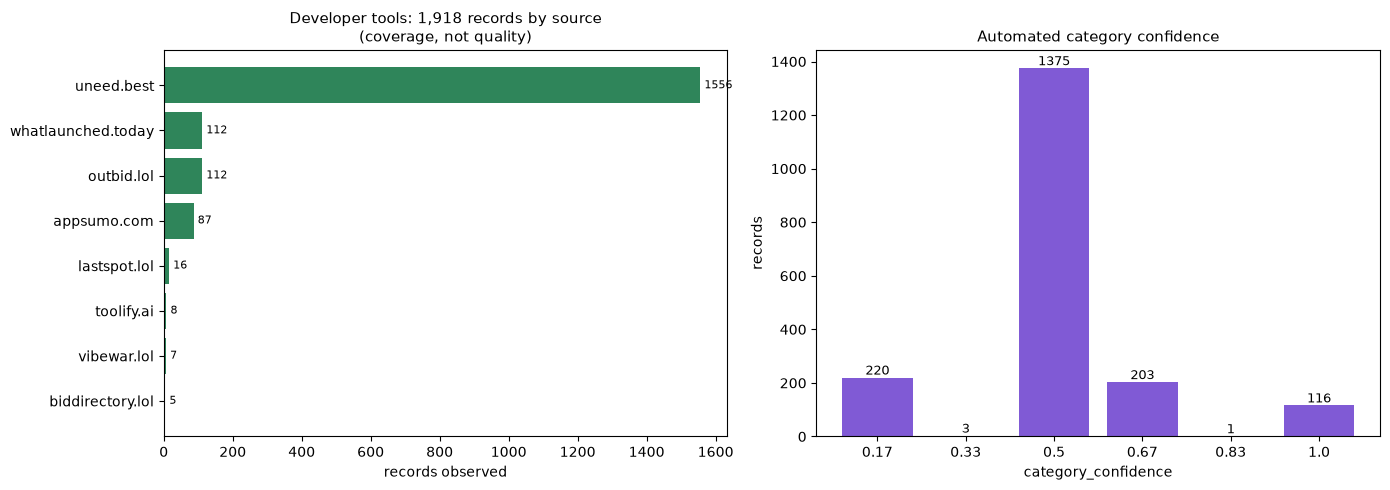

In [8]:
top_sources = sources.head(8).iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top_sources["discovered_from"], top_sources["recordCount"], color="#2f855a")
axes[0].set_xlabel("records observed")
axes[0].set_title(f"Developer tools: {len(devtools):,} records by source\n(coverage, not quality)", fontsize=11)
for y, v in enumerate(top_sources["recordCount"]):
    axes[0].text(v, y, f" {int(v)}", va="center", fontsize=8)

bars = axes[1].bar(confidence["category_confidence"].astype(str),
                   confidence["records"], color="#805ad5")
axes[1].set_xlabel("category_confidence")
axes[1].set_ylabel("records")
axes[1].set_title("Automated category confidence", fontsize=11)
for bar, v in zip(bars, confidence["records"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v, f"{int(v)}",
                 ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## Findings

In [9]:
top_source = sources.iloc[0]
full_conf = int((devtools["category_confidence"] >= 1.0).sum())
low_conf = int((devtools["category_confidence"] <= 0.5).sum())

findings = [
    f"The developer-tools slice covers {coverage['records']:,} records across "
    f"{coverage['distinctDomains']:,} distinct domains.",

    f"{coverage['onRankBoard']:,} of {coverage['records']:,} records "
    f"({coverage['onRankBoardPct']}%) appear on the Harpd Rank board.",

    f"Records come from {coverage['distinctDiscoverySources']} discovery sources; "
    f"'{top_source['discovered_from']}' alone accounts for "
    f"{int(top_source['recordCount']):,} records ({top_source['sharePct']}%).",

    f"Category confidence: {full_conf:,} records at 1.0 "
    f"({full_conf/coverage['records']*100:.2f}%), {low_conf:,} at 0.5 or below "
    f"({low_conf/coverage['records']*100:.2f}%). Mean {coverage['meanCategoryConfidence']}.",

    f"Domain overlap with the agent slice: {len(dev_domains & agent_domains):,}. "
    f"With the AI-tools slice: {len(dev_domains & tool_domains):,}. "
    "The developer slice is therefore disjoint from the other published slices.",

    f"Union across all three slices: {len(dev_domains | agent_domains | tool_domains):,} "
    "distinct domains.",

    "This slice is a coverage view, not a ranking, and no product here is ordered "
    "by quality.",
]

for i, line in enumerate(findings, 1):
    print(f"{i}. {line}")

1. The developer-tools slice covers 1,918 records across 1,918 distinct domains.
2. 0 of 1,918 records (0.0%) appear on the Harpd Rank board.
3. Records come from 15 discovery sources; 'uneed.best' alone accounts for 1,556 records (81.13%).
4. Category confidence: 116 records at 1.0 (6.05%), 1,598 at 0.5 or below (83.32%). Mean 0.5103.
5. Domain overlap with the agent slice: 0. With the AI-tools slice: 0. The developer slice is therefore disjoint from the other published slices.
6. Union across all three slices: 2,611 distinct domains.
7. This slice is a coverage view, not a ranking, and no product here is ordered by quality.


## Limitations

- **Coverage, not ranking.** The slice records observed developer tools, not the
  best ones.
- One discovery source dominates the slice, so the slice describes that source's
  catalog at least as much as it describes the developer-tools market.
- Category assignment is automated and often low-confidence.
- No usage, install, revenue or retention metric exists in the data.
- Domain-based overlap is a lower bound on true product overlap: two records for
  the same product on different domains will not be detected.
- A single observation window means no trend can be measured.
- 1,918 records is a count of discovered listings. It is not a market size.


## Reproducibility

In [10]:
import platform
import sys

print("Reproduce this notebook")
print("=" * 60)
print("python :", sys.version.split()[0], "on", platform.platform())
print("pandas :", pd.__version__)
print("data   :", loader.resolved_data_base())
print()
print("From a clean machine:")
print("  git clone https://github.com/harpd-dev/harpd-ai-research-notebooks")
print("  cd harpd-ai-research-notebooks")
print("  python -m venv .venv && . .venv/bin/activate")
print("  pip install -r requirements.txt")
print("  jupyter nbconvert --to notebook --execute --inplace notebooks/<this file>")
print()
print("Offline / pinned snapshot:")
print("  HARPD_DATA_BASE=/path/to/harpd-ai-datasets/ jupyter nbconvert ...")


Reproduce this notebook
python : 3.13.12 on macOS-26.6.2-arm64-arm-64bit-Mach-O
pandas : 3.0.5
data   : https://raw.githubusercontent.com/harpd-dev/harpd-ai-datasets/main/

From a clean machine:
  git clone https://github.com/harpd-dev/harpd-ai-research-notebooks
  cd harpd-ai-research-notebooks
  python -m venv .venv && . .venv/bin/activate
  pip install -r requirements.txt
  jupyter nbconvert --to notebook --execute --inplace notebooks/<this file>

Offline / pinned snapshot:
  HARPD_DATA_BASE=/path/to/harpd-ai-datasets/ jupyter nbconvert ...


## Sources

- Dataset registry: <https://github.com/harpd-dev/harpd-ai-datasets>
- Canonical data home: <https://harpd.com/data/>
- File: `data/research/developer-tools-index.json`
- Discovery surface (publisher): <https://harpd.com/discovery/>
- Licence: CC BY 4.0

**Licence.** All Harpd dataset content is published under CC BY 4.0.

**Attribution.** Harpd (<https://harpd.com>).

**Not a source for.** Product quality, traffic, revenue, review scores or
market size. None of those are measured by these datasets, and none are
estimated in this notebook.
